# 2025/26 Artificial Intelligence (U19967) - Lab on Supervised Learning
Adedayo Olowolayemo, Msc AFHEA

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  

***************************************************************************************************************************

## Two techniques
###  - Principal Component Analysis
###  - KMeans Clustering

******************************************************************************************************

# ![Iris Metadata](https://hub.2i2c.mybinder.org/user/profdee92-ai-rise-note-xrt2ibhu/files/Iris%20Metadata.png)

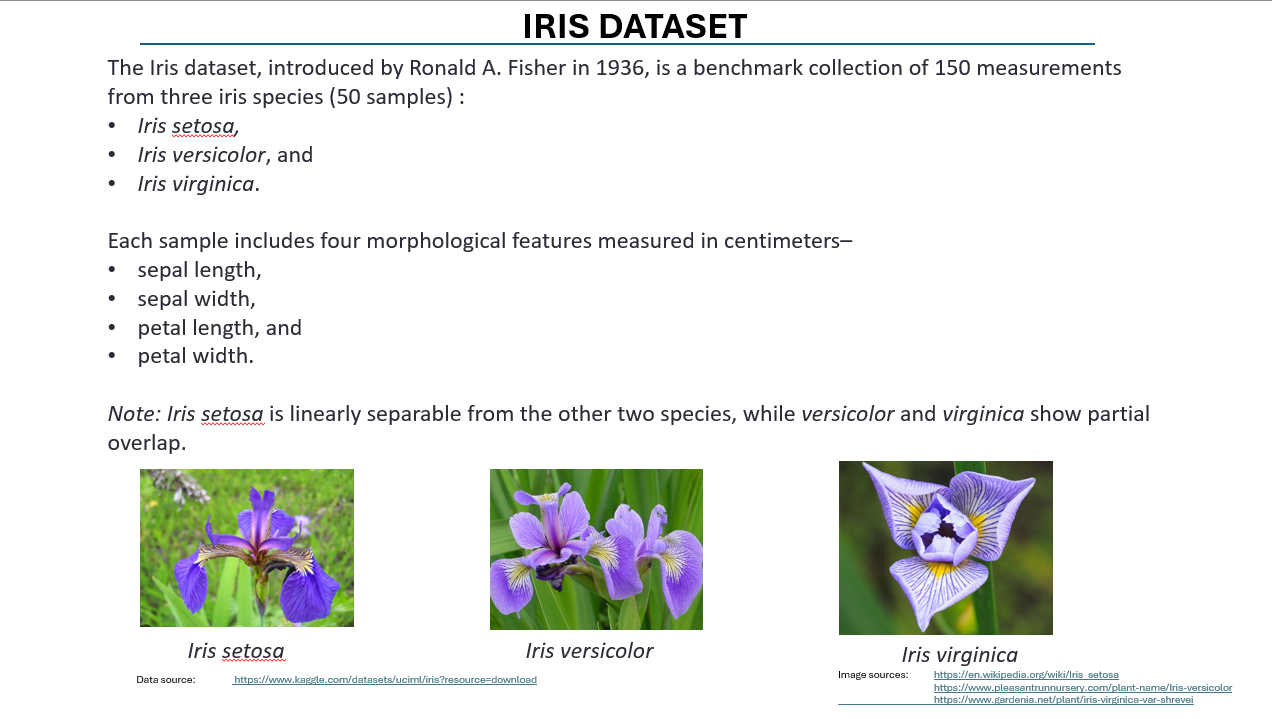

In [8]:
from IPython.display import Image, display
display(Image("Iris Metadata.png"))  

*************************************************************************************************************

************************************************************************************************************

## Unsupervised ML Techniques - KMeans Clustering

### We import all dependecies

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Load data

In [19]:

# 1. Load Data & Create DataFrame

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]  # Only petal length & width (for clear 2D)
feature_names = ['petal length (cm)', 'petal width (cm)']

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

print(" BEFORE STANDARDIZATION — First 5 rows:")
print(df.head().round(3))
print()



 BEFORE STANDARDIZATION — First 5 rows:
   petal length (cm)  petal width (cm) species
0                1.4               0.2  setosa
1                1.4               0.2  setosa
2                1.3               0.2  setosa
3                1.5               0.2  setosa
4                1.4               0.2  setosa



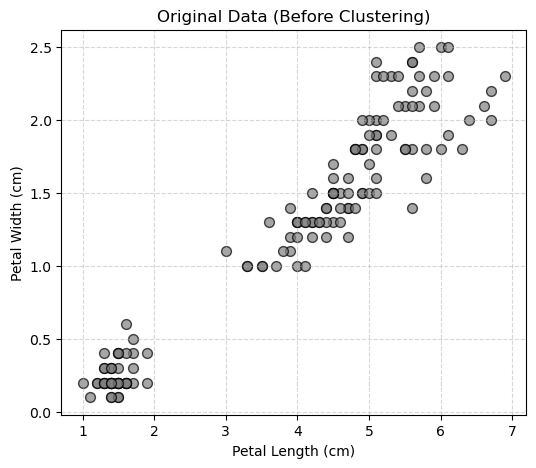

In [21]:

# 2. Plot Original Data (Before Clustering)

plt.figure(figsize=(6, 5))
plt.scatter(df['petal length (cm)'], df['petal width (cm)'],
            c='gray', alpha=0.7, edgecolor='k', s=50)
plt.title('Original Data (Before Clustering)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [23]:

# 3. Standardize & Show Table

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=[f'{f} (scaled)' for f in feature_names])
print(" AFTER STANDARDIZATION — First 5 rows:")
print(df_scaled.head().round(3))
print()



 AFTER STANDARDIZATION — First 5 rows:
   petal length (cm) (scaled)  petal width (cm) (scaled)
0                      -1.340                     -1.315
1                      -1.340                     -1.315
2                      -1.397                     -1.315
3                      -1.283                     -1.315
4                      -1.340                     -1.315



#### K-Means uses Euclidean distance. If one feature has a much larger scale (like petal length: 1-7 cm) than another (sepal width: 2-4 cm), it will  dominate the distance calculation - making other features irrelevant.

#### Standardization ensures:
####     All features have mean = 0, std = 1
####     No feature dominates due to scale
####     Clustering is based on relative shape, not absolute size


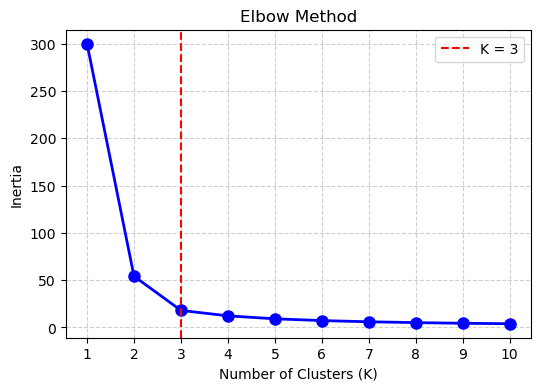

In [26]:

# 4. Elbow Method

K_range = range(1, 11)
inertias = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)



plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='K = 3')
plt.title('Elbow Method')



plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



In [28]:

# 5. Apply K-Means (K=3)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Transform centroids back to original scale
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)



### The code fits a K-Means clustering model with 3 clusters on the standardized feature data X_scaled, using a fixed random_state=42 for reproducibility and n_init=10 to run the algorithm 10 times with different centroid seeds to avoid poor local minima. 

### The fit_predict() method assigns each sample to its nearest cluster, returning cluster labels in y_kmeans.

Since clustering was performed in the scaled space, the resulting centroids (stored in kmeans.cluster_centers_) are also in standardized units; to interpret or plot them in the original measurement scale (e.g., centimeters for petal dimensions)

#### scaler.inverse_transform() is applied, to convert the centroids back to the original feature space - enabling meaningful visualization and comparison with the raw data.

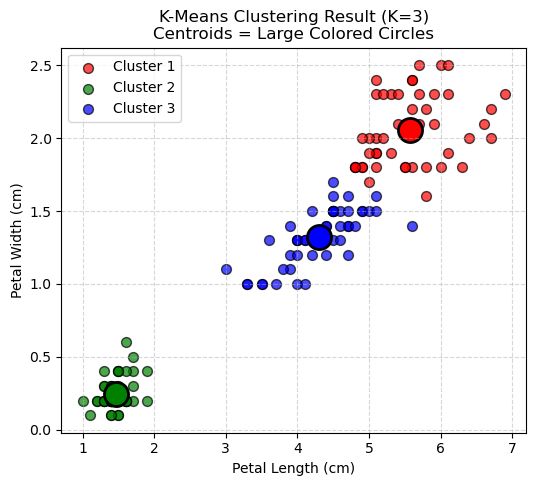

In [30]:

# 6. Final Clustering Plot — Centroids as Large Colored Circles

plt.figure(figsize=(6, 5))
colors = ['red', 'green', 'blue']
for i in range(3):
    mask = y_kmeans == i
    plt.scatter(X[mask, 0], X[mask, 1],
                c=colors[i], label=f'Cluster {i+1}',
                alpha=0.7, edgecolor='k', s=50)
    # Centroid: large circle, same color, no edge
    plt.scatter(centroids_orig[i, 0], centroids_orig[i, 1],
                c=colors[i], s=300, marker='o', edgecolor='black', linewidth=2)

plt.title('K-Means Clustering Result (K=3)\nCentroids = Large Colored Circles')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



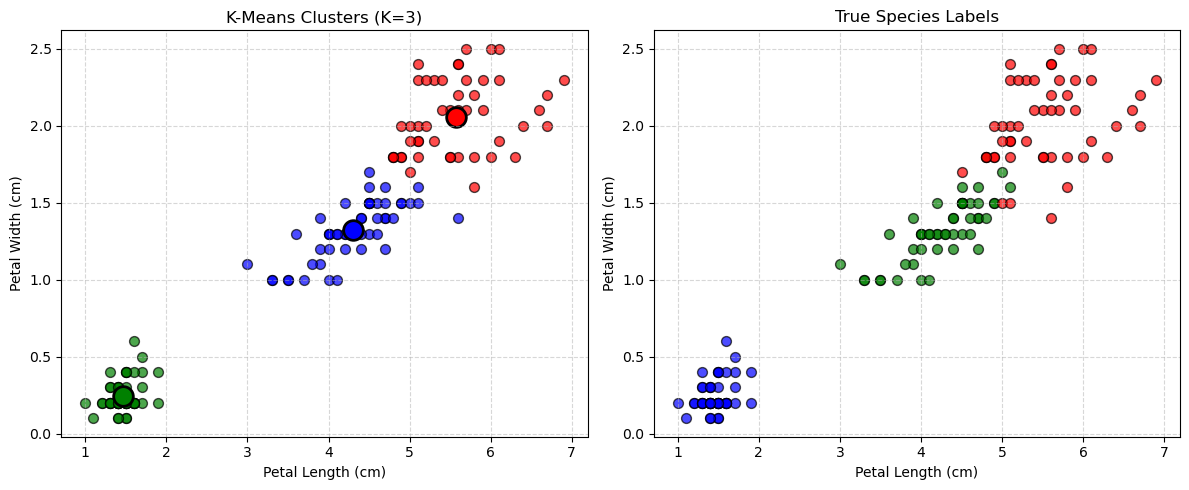

In [32]:
# 7. Side-by-Side: K-Means vs True Labels

species_colors = {'setosa': 'blue', 'versicolor': 'green', 'virginica': 'red'}
df['color'] = df['species'].map(species_colors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
for i in range(3):
    mask = y_kmeans == i
    axes[0].scatter(X[mask, 0], X[mask, 1], c=colors[i], alpha=0.7, edgecolor='k', s=50)
    axes[0].scatter(centroids_orig[i, 0], centroids_orig[i, 1],
                    c=colors[i], s=200, marker='o', edgecolor='black', linewidth=2)
axes[0].set_title('K-Means Clusters (K=3)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# True Labels
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                    c=species_colors[species], alpha=0.7, edgecolor='k', s=50)
axes[1].set_title('True Species Labels')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Unsupervised ML Techniques - Principal Component Analysis (PCA)
 
 
 We will be using the popular Iris Dataset.
 
 But before we proceed, it is good to understand our dataset 


## Step 1: Load and Inspect Original Data

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets



# Load data
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names




In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets



# Load data
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names




## Step 2: Standardize the Features

In [41]:
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



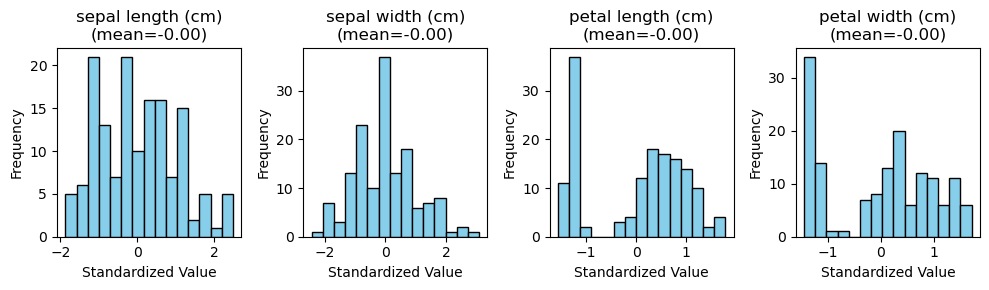

In [43]:

# Verify standardization
plt.figure(figsize=(10, 3))
for i, name in enumerate(feature_names):
    plt.subplot(1, 4, i+1)
    plt.hist(X_scaled[:, i], bins=15, color='skyblue', edgecolor='k')
    plt.title(f'{name}\n(mean={X_scaled[:,i].mean():.2f})')
    plt.xlabel('Standardized Value')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Step 3: Fit Full PCA and Show Scree Plot

In [46]:
from sklearn.decomposition import PCA

# Fit PCA with all components (n=4)
pca = PCA()
pca.fit(X_scaled)

PCA()

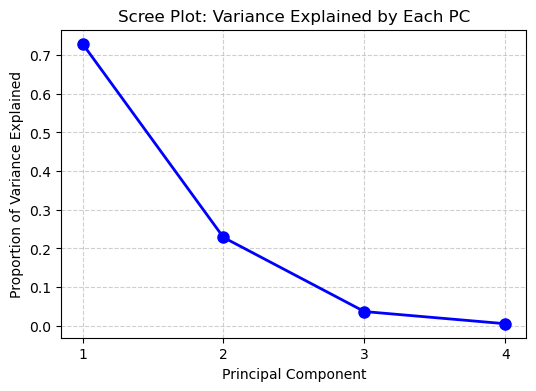

In [48]:

# Scree plot: variance per PC
plt.figure(figsize=(6, 4))
PCs = np.arange(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(PCs, pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.title('Scree Plot: Variance Explained by Each PC')

plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(PCs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Step 4: Cumulative Variance Explained

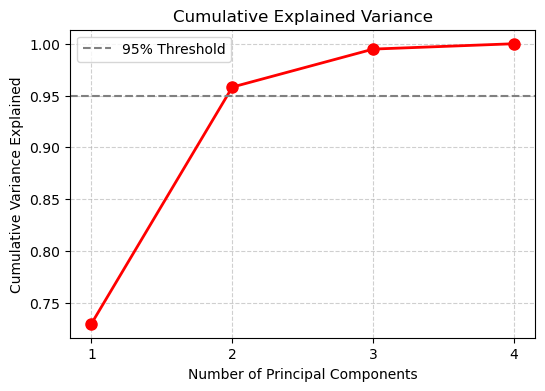

→ 2 PCs explain 95.8% of total variance.


In [51]:

# Cumulative variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(PCs, cumulative_var, 'ro-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')


plt.ylabel('Cumulative Variance Explained')
plt.xticks(PCs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Print key insight
print(f"→ 2 PCs explain {cumulative_var[1]:.1%} of total variance.")



## Step 5: Project Data onto First 2 PCs

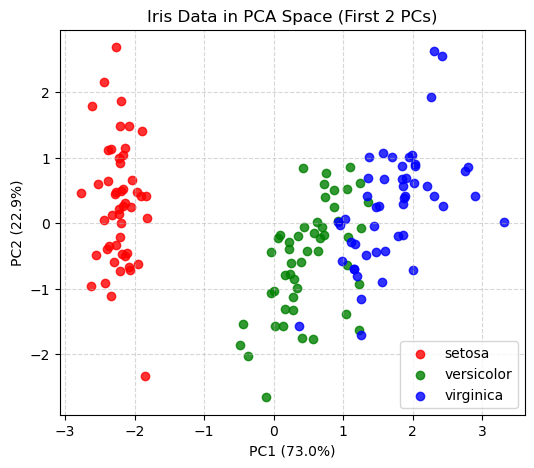

In [54]:

# Transform data to 2D
X_pca = pca.transform(X_scaled)[:, :2]



# Plot PCA result
plt.figure(figsize=(6, 5))
for i, color in enumerate(colors):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], c=color, label=target_names[i], alpha=0.8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Iris Data in PCA Space (First 2 PCs)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()